In [16]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

class FolderMonitor:
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.existing_files = set(os.listdir(folder_path))

    def monitor(self):
        while True:
            current_files = set(os.listdir(self.folder_path))
            new_files = current_files - self.existing_files

            if new_files:
                for file_name in new_files:
                    file_path = os.path.join(self.folder_path, file_name)
                    try:
                        data = np.fromfile(file_path, np.complex64)  # Read file into numpy array
                        print(f"New file detected: {file_name}")
                        print(data.shape)
                        plt.clf()
                        plt.plot(np.real(data[0:1024]))
                        plt.show()
                    except Exception as e:
                        print(f"Error reading file {file_name}: {e}")

                self.existing_files = current_files  # Update existing files

            time.sleep(1)  # Check every second

In [17]:
# folder_path = "../script/dataFolder"  # Replace with the actual folder path
# monitor = FolderMonitor(folder_path)
# monitor.monitor()

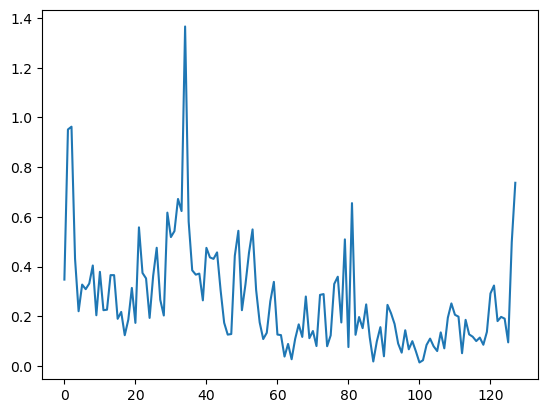

In [24]:
data = np.load("../gui/rangeProfile/scan_0.npy")
plt.plot(np.abs(data))

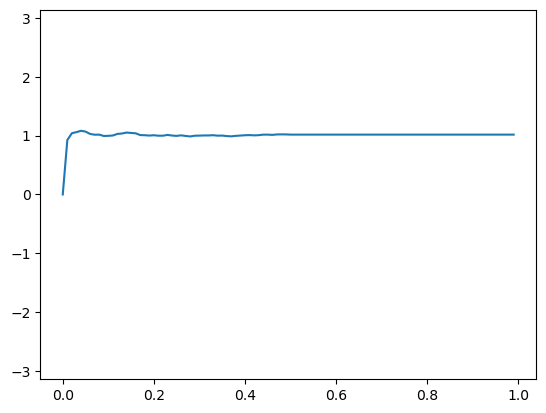

In [34]:
phase = np.angle(output/tx)
plt.ylim([-np.pi,np.pi])
plt.plot(t,phase)

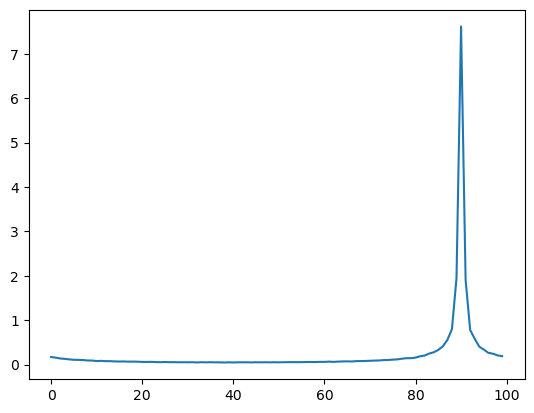

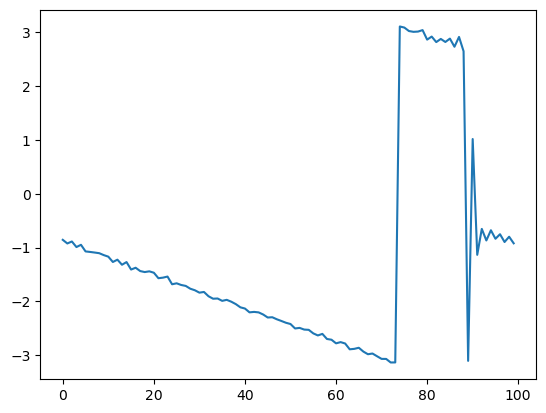

In [36]:
output_f = np.fft.ifft(output)
plt.plot(np.abs(output_f))
plt.figure()
plt.plot(np.angle(output_f))